In [1]:
import sys
sys.path.insert(0, "..") 
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import os
import src.kz as kz
DOF   = kz.DOF      # lattice sites (1024)
N_WIN = 11
FONTSIZE = 16



Following the original paper, we build a simple recurrent neural network to model the one dimensional snapshots. 
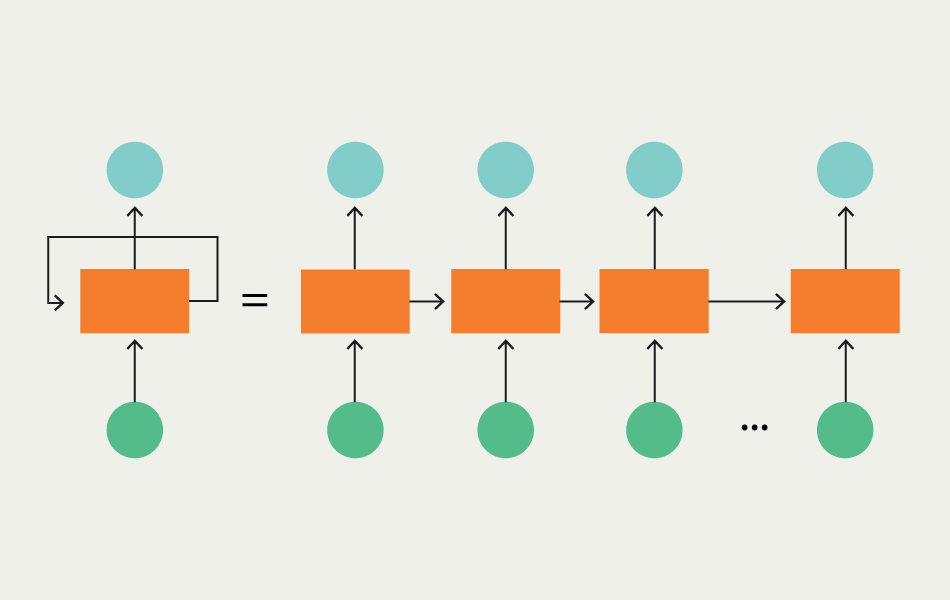

A recurrent nueral network approximates real-time processes as a series of snapshots, the idea being the model should learn to infer the dynamics of time evolution. 


By using five snapshots of the field configuration in the freezeout regime, the model is able to learn the momentum of the field.

Let's design our simple model

In [2]:

def build_model():
    """SimpleRNN over the time window -> final field at every site (as in the original paper)."""
    model = keras.Sequential([
        keras.layers.Input(shape=(N_WIN, DOF)),
        keras.layers.SimpleRNN(256, activation="softsign"),
        keras.layers.Dense(DOF),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

KZ_model = build_model()
KZ_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       263,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,104 (2.25 MB)

 Trainable params: 591,104 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Now we need data on which to train the model. Using a simple numerical integrator, we generate thousands of field trajectories over the quench.

We have data generated for this repository, but you can choose your own values of $\tau$ by running `python -m scripts/kz1d/generate_data.py <TAU>` (This may take a while!)

With the data generated, we load it into the notebook and choose our preferred sample time

In [3]:
d = kz.load(128, outdir='../data')
T_SAMPLE = 50

Now we'll prep our tensors for training.

In [4]:

X = kz.window(d, T_SAMPLE).astype('float32')     # (N, 11, 1024)
Y = d['phi_final'].astype('float32')            # (N, 1024)
print(X.shape, Y.shape)
#Useful for normalization
print('input  scale:', np.abs(X).std()) 
print('target scale:', np.abs(Y).std())

(3000, 11, 1024) (3000, 1024)
input  scale: 0.008369446
target scale: 0.16179712


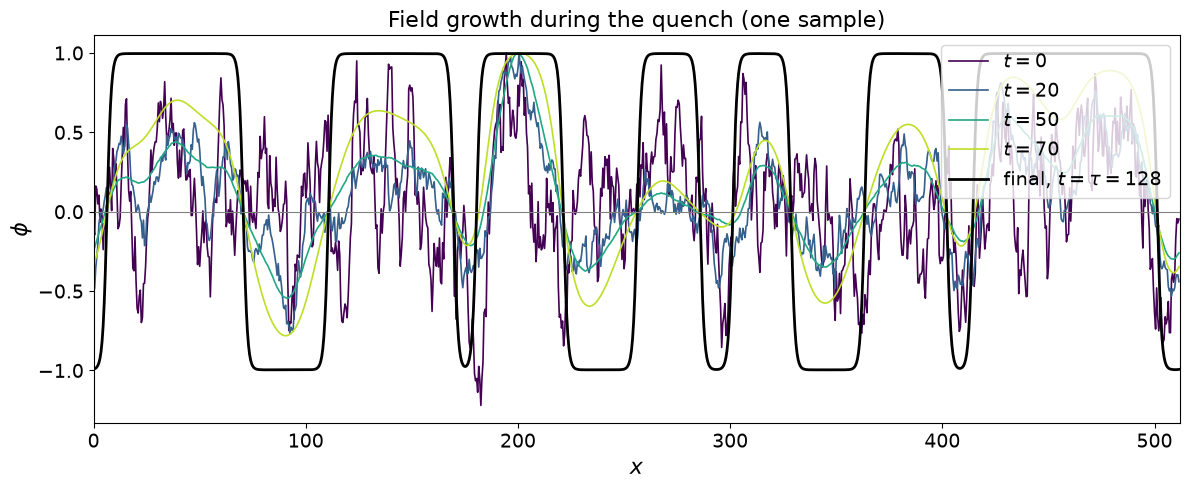

In [5]:
# ---- inputs ----
T_LIST   = [0, 20, 50, 70]   # times to show
SAMPLE   = -1                # which sample (any index; -1 = last, a validation sample)

ts = d["ts"]
x  = kz.grid()
colors = plt.cm.viridis(np.linspace(0, 0.9, len(T_LIST)))

plt.figure(figsize=(12, 5))
for t, c in zip(T_LIST, colors):
    j = int(np.argmin(np.abs(ts - t)))          # nearest stored snapshot
    sample = d["phi_hist"][SAMPLE, j]
    plt.plot(x, sample/sample.max(), color=c, lw=1.2, label=rf"$t = {ts[j]:.0f}$")
plt.plot(x, d["phi_final"][SAMPLE], "k-", lw=2, label=rf"final, $t = \tau = {128}$")

plt.axhline(0, color="grey", lw=0.8)
plt.xlim(0, kz.L())
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.ylabel(r"$\phi$", fontsize=FONTSIZE)
plt.title("Field growth during the quench (one sample)", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2, loc="upper right")
plt.tight_layout()
plt.show()

We can see from the above plot that the field evolves from complete disorder, to an almost binary bit string corresponding to degenerate ground state domains of the system. The question being analyzed is how much information is contained in early time evolution?

Now let's train our model

In [6]:
hist = KZ_model.fit(X, Y, epochs=60, batch_size=10, validation_split=0.2)

Epoch 1/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5719 - val_loss: 0.4099
Epoch 2/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3605 - val_loss: 0.3297
Epoch 3/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2977 - val_loss: 0.2758
Epoch 4/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2544 - val_loss: 0.2457
Epoch 5/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2228 - val_loss: 0.2188
Epoch 6/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1985 - val_loss: 0.2013
Epoch 7/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1767 - val_loss: 0.1853
Epoch 8/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1615 - val_loss: 0.1612
Epoch 9/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1455 - val_loss: 0.1544
Epoch 10/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1364 - val_loss: 0.1430
Epoch 11/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1237 - val_loss: 0.1416
Epoch 12/60
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

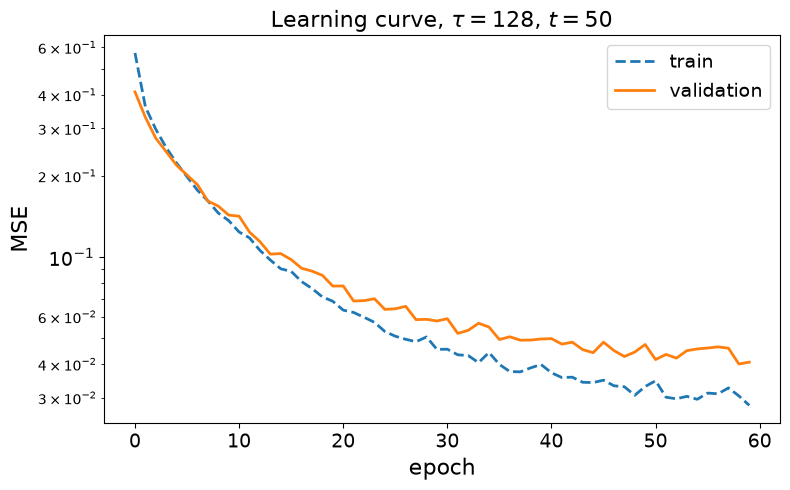

In [7]:
FONTSIZE = 16

plt.figure(figsize=(8, 5))
plt.plot(hist.history["loss"],     "--", lw=2, label="train")
plt.plot(hist.history["val_loss"], "-",  lw=2, label="validation")
plt.xlabel("epoch", fontsize=FONTSIZE)
plt.ylabel("MSE", fontsize=FONTSIZE)
plt.yscale("log")
plt.title(rf"Learning curve, $\tau = {int(kz.TAU)}$, $t = {T_SAMPLE}$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.show()

As we can see, the model trains well, and that training extend to the validation data it has not seen.

Let's visualize now what our model actually learned:

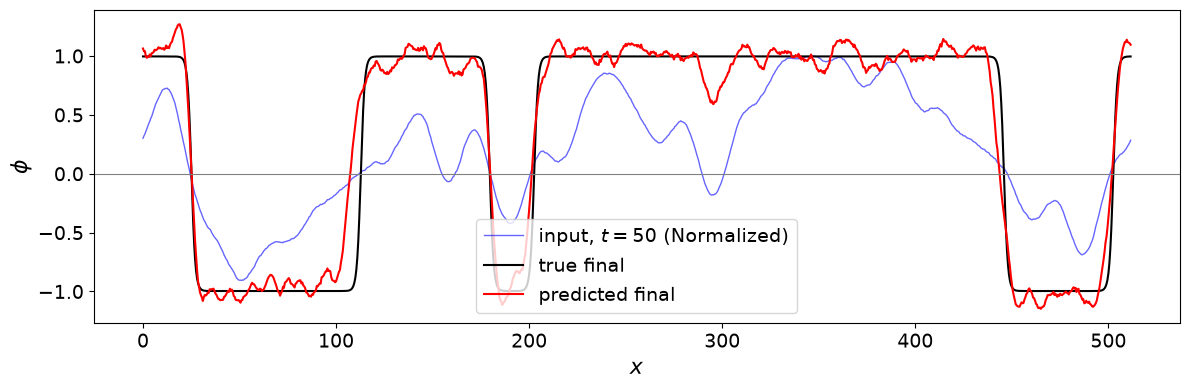

In [11]:
N_VAL  = int(0.2 * len(X))   # Keras validation_split holds out the last 20%
SAMPLE = 4                # which validation sample to plot
MID    = N_WIN // 2          # middle snapshot of the input window (index 5, time t = T_SAMPLE)
X_val, Y_val = X[-N_VAL:], Y[-N_VAL:]
Y_pred = KZ_model.predict(X_val, verbose=0)

plt.figure(figsize=(12, 4))
plt.plot(kz.grid(), X_val[SAMPLE, MID]/np.abs(X_val[SAMPLE, MID].max()), "b-", lw=1.0, alpha=0.6, label=rf"input, $t = {T_SAMPLE}$ (Normalized)")
plt.plot(kz.grid(), Y_val[SAMPLE],      "k-", lw=1.5, label="true final")
plt.plot(kz.grid(), Y_pred[SAMPLE],     "r-", lw=1.5, label="predicted final")
plt.axhline(0, color="grey", lw=0.8)
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.ylabel(r"$\phi$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/1d/Predicted_Final_1d.png",dpi=500)
plt.show()

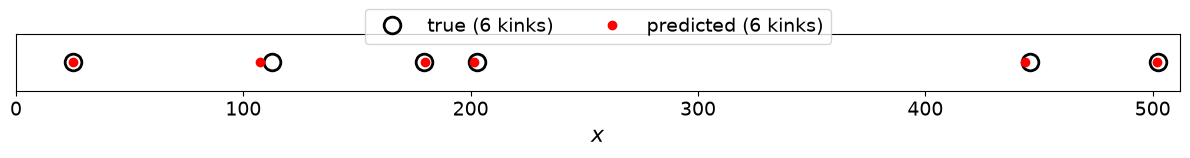

In [12]:

# kink positions: where phi crosses zero (interpolated), true vs predicted
x_true = kz.defect_positions(Y_val[SAMPLE].astype(np.float64))
x_pred = kz.defect_positions(Y_pred[SAMPLE].astype(np.float64))

plt.figure(figsize=(12, 2.5))
plt.plot(x_true, np.zeros(len(x_true)), "o", mfc="none", mec="k", ms=12, mew=2,
         label=f"true ({len(x_true)} kinks)")
plt.plot(x_pred, np.zeros(len(x_pred)), "o", color="r", ms=6,
         label=f"predicted ({len(x_pred)} kinks)")
plt.xlim(0, kz.L())
plt.yticks([])
plt.xlabel(r"$x$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2, loc="upper center", bbox_to_anchor=(0.5, 1.6), ncol=2)
plt.tight_layout()
plt.savefig("../figures/1d/defect_location_prediction.png",dpi=500)
plt.show()

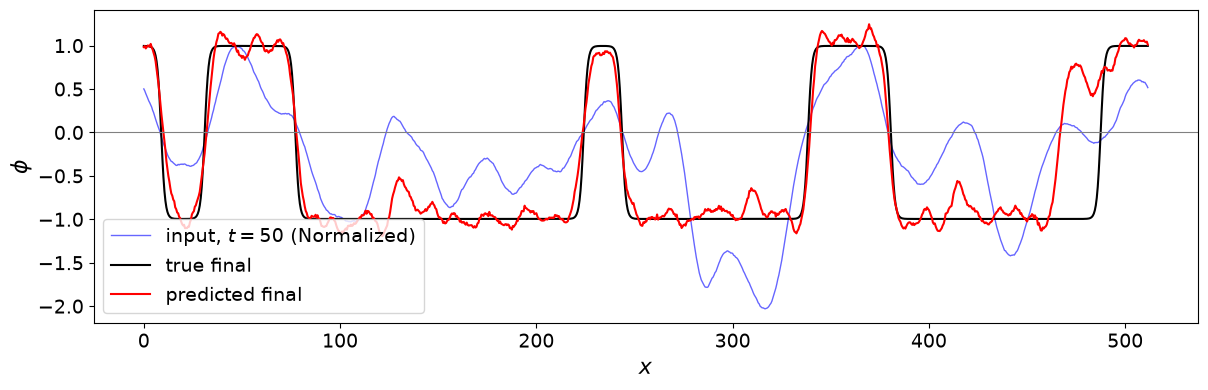
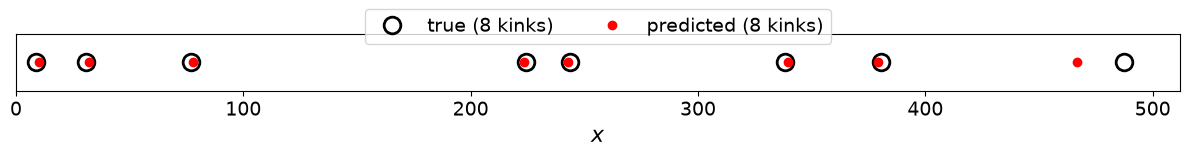

The model is able to learn not only the number of the Kibble-zurek domains, but the locations of them as well.

Now consider the same run, but evaluated at different times. We should expect that there is no final-domain information held at times before the KZ freezout begins, and that the model should be able to do increasingly well the closer we are to the final configuration.

In [13]:
# ---- inputs ----
TAU      = 128
T_LIST   = [-80, -5, 20, 50, 70]
COLORS   = ["red", "darkorange", "purple", "blue", "green"]
EPOCHS   = 60

Y_all = d["phi_final"].astype("float32")

hists = {}
for t in T_LIST:
    Xt = kz.window(d, t).astype("float32")
    m  = build_model()
    h  = m.fit(Xt, Y_all, epochs=EPOCHS, batch_size=10, validation_split=0.2, verbose=0)
    hists[t] = h.history
    print(f"t = {t:4d}   final train = {h.history['loss'][-1]:.3f}   final val = {h.history['val_loss'][-1]:.3f}")



t =  -80   final train = 0.693   final val = 1.067
t =   -5   final train = 0.484   final val = 0.803
t =   20   final train = 0.218   final val = 0.278
t =   50   final train = 0.029   final val = 0.039
t =   70   final train = 0.018   final val = 0.027


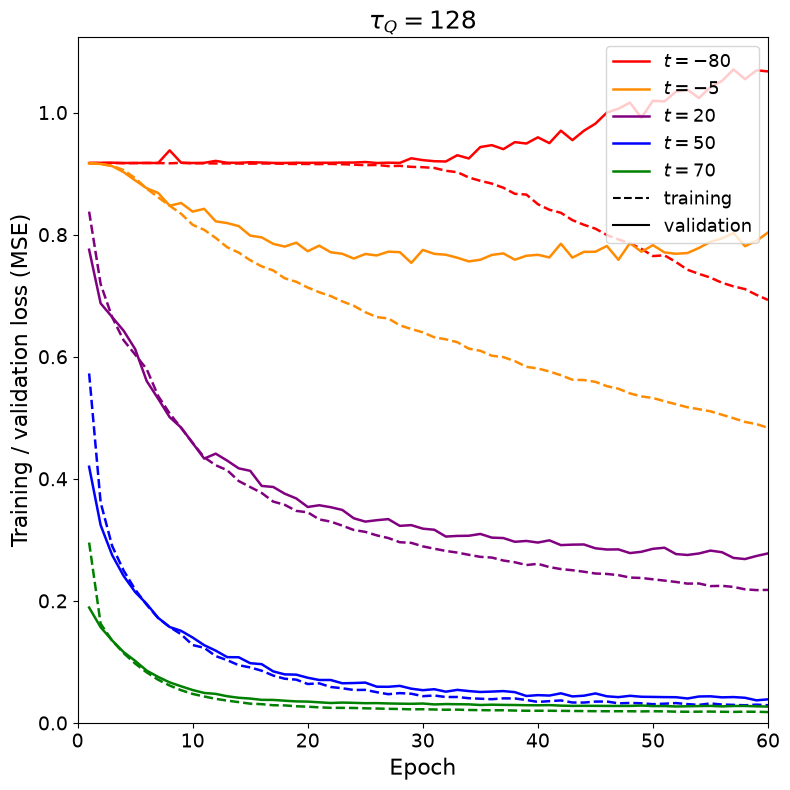

In [15]:
# ---- plot: dashed = training, solid = validation ----
epochs = np.arange(1, EPOCHS + 1)
plt.figure(figsize=(8, 8))
for t, c in zip(T_LIST, COLORS):
    plt.plot(epochs, hists[t]["loss"],     "--", color=c, lw=1.8)
    plt.plot(epochs, hists[t]["val_loss"], "-",  color=c, lw=1.8, label=rf"$t = {t}$")

plt.plot([], [], "k--", label="training")      # legend entries for line style
plt.plot([], [], "k-",  label="validation")

plt.xlabel("Epoch", fontsize=FONTSIZE)
plt.ylabel("Training / validation loss (MSE)", fontsize=FONTSIZE)
plt.title(rf"$\tau_Q = {TAU}$", fontsize=FONTSIZE + 2)
plt.xlim(0, EPOCHS)
plt.ylim(0, None)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 3, loc="upper right")
plt.tight_layout()
plt.savefig("../figures/1d/final_t_validation_curves.png",dpi=500)
plt.show()

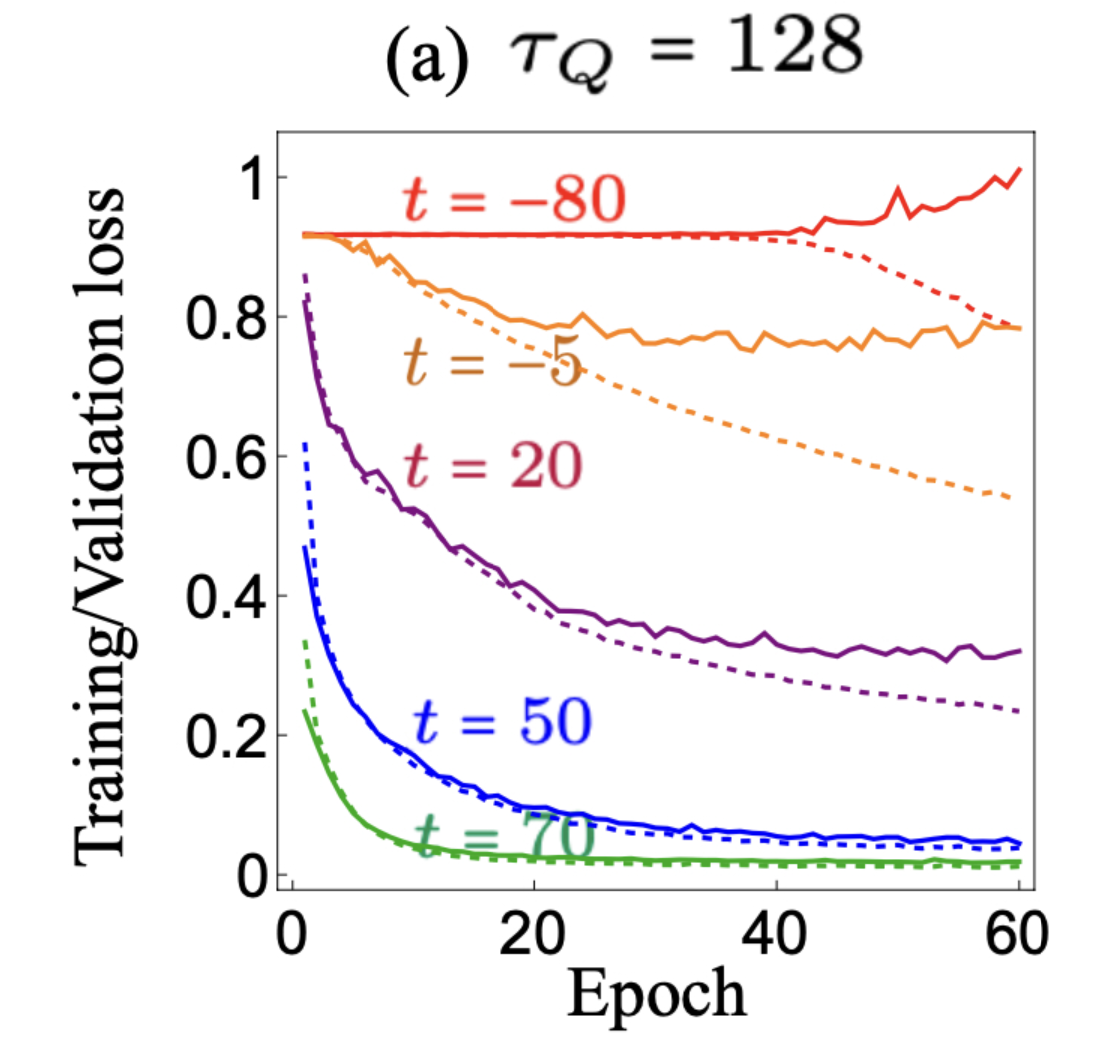

We find good qualitative analysis with the paper's results.

Going beyond the paper's immediate results, we can investigate how much of the information is really held in the excited kibble-zurek modes.

In [18]:
# ---- inputs ----
T_SAMPLE = 50
KC_MULT  = np.linspace(0.1,2,12)      # cutoffs in units of 1/xi_hat
EPOCHS   = 60
FONTSIZE = 16

xi_hat = np.sqrt(2) * (TAU / (2 * kz.eta))**0.25
k_hat  = 1 / xi_hat

X = kz.window(d, T_SAMPLE).astype("float32")
Y = d["phi_final"].astype("float32")
k = 2 * np.pi * np.fft.rfftfreq(X.shape[-1], d=kz.dx)   # wavenumbers of the lattice

# ---- train on unfiltered input (reference) ----
m = build_model()
h = m.fit(X, Y, epochs=EPOCHS, batch_size=10, validation_split=0.2, verbose=0)
val_full = h.history["val_loss"][-1]
print(f"no filter:         val = {val_full:.4f}")

# ---- train on low-pass filtered input: keep only modes with k < kc ----
val = []
for mult in KC_MULT:
    F = np.fft.rfft(X, axis=-1)
    F[..., k > mult * k_hat] = 0
    Xf = np.fft.irfft(F, n=X.shape[-1], axis=-1).astype("float32")

    m = build_model()
    h = m.fit(Xf, Y, epochs=EPOCHS, batch_size=10, validation_split=0.2, verbose=0)
    val.append(h.history["val_loss"][-1])
    print(f"kc = {mult:5.2f}/xi_hat:  val = {val[-1]:.4f}")

# ---- plot ----
plt.figure(figsize=(8, 5))
plt.plot(KC_MULT, val, "o-", ms=9, lw=2, label="low-pass input")
plt.axhline(val_full, color="k", ls="--", lw=1.5, label="no filter")
plt.axvline(1, color="grey", ls=":", lw=1.5)
plt.xscale("log")
plt.xlabel(r"cutoff $k_c \, \hat\xi$", fontsize=FONTSIZE)
plt.ylabel("validation MSE", fontsize=FONTSIZE)
plt.title(rf"$\tau_Q = {TAU}$, $t = {T_SAMPLE}$", fontsize=FONTSIZE)
plt.tick_params(labelsize=FONTSIZE - 2)
plt.legend(fontsize=FONTSIZE - 2)
plt.tight_layout()
plt.savefig("../figures/1d/lowpass_training.png",dpi=500)
plt.show()

KeyboardInterrupt: 

In the above experiment, we low-pass filter the input, keeping only modes with $k<k_c$. If we make $k_c< 1/\xi_{KZ}$, our models ability to predict the final configuration drops dramatically.

By excluding momentum modes larger than $1/\xi_{KZ}$, we find that we lose very little information. The model's ability to learn the final configuration is determined by this length scale!